# 04 · Joint and SNe vs BAO comparisons

Four scenarios that cross SNe (Pantheon+SH0ES) with BAO (DESI DR2):

- §4.1 **Joint w0waCDM**: ML 4D trained on chi2_sne + chi2_bao (standard pipeline).
- §4.2 **Joint with Om=0.40 prior**: ML 3D variant with an arbitrary Gaussian
  Om prior (robustness test).
- §4.3 **w0–wa overlay ellipses**: exact theory grids for SNe and BAO overlaid
  (no ML).
- §4.4 **1D wa constraint**: Delta-chi2(wa) for each probe at fixed w0=-1 (no ML).


## Index

| Sec. | Scenario                              | Data                                  | Cepheids | Uses ML |
|------|---------------------------------------|---------------------------------------|----------|---------|
| [4.1](#4-1) | **Joint w0waCDM (ML 4D)**       | Pantheon+SH0ES + DESI BAO             | **YES**  | Yes     |
| [4.2](#4-2) | **Joint with Om=0.40 prior**    | Pantheon+SH0ES + DESI BAO + Om prior  | **YES**  | Yes (ML 3D) |
| [4.3](#4-3) | **w0–wa ellipses: SNe vs BAO**  | Pantheon+SH0ES + DESI BAO             | **YES**  | No (theory grid) |
| [4.4](#4-4) | **Delta-chi2(wa) 1D**           | Pantheon+SH0ES + DESI BAO             | **YES**  | No (1D scan) |

> §4.1 and §4.2 use standard ML with cache. §4.3 and §4.4 are analytic
> SNe-vs-BAO comparisons in low-dimensional spaces (no ML).


## <a id="setup"></a>Setup (run first)


In [5]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_pantheon_plus, load_desi_bao
from cosmoml.theory import chi2_joint, chi2_sne, chi2_bao
from cosmoml.priors import gaussian_prior
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR, PLANCK_H0, PLANCK_RD, PLANCK_OM

use_paper_style()

NB_NAME = "04_SN+BAO"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False

sne = load_pantheon_plus(apply_mask=True)
bao = load_desi_bao()
print(f"Pantheon+ with SH0ES: {len(sne)} SNe, calibradores={sne.is_calib.sum()}")
print(f"DESI BAO full:   {len(bao)} measurements")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Pantheon+ with SH0ES: 1657 SNe, calibradores=77
DESI BAO completo:   13 medidas


## <a id="4-1"></a>4.1 Joint Pantheon+SH0ES + DESI BAO — w0waCDM 4D

**Model:** `Flatw0waCDM` (Om, H0, w0, wa).
**Data:** Pantheon+SH0ES (mask z>0.01 OR calibrators, 1701 SNe) + DESI BAO DR2 (rd=147.09).
**Cepheids:** YES. M analytically marginalized. rd at Planck fiducial.

Pipeline:
1. **Auto-center** the best-fit with Minuit before generating slices — otherwise the dataset is centred on the Planck/ΛCDM point (not the joint best-fit) and contours come out off-centre.
2. **Six slices** covering all parameter pairs in 4D (w0-wa, Om-w0, H0-w0,
   Om-wa, H0-wa, Om-H0), all centered on the best-fit.
3. **Wide random box**: Om in (0.1, 0.6), H0 in (60, 85), w0 in (-3.0, 0.2),
   wa in (-3.0, 2.0).


In [6]:
SECTION = "4_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "H0", "w0", "wa"]

def chi2_fn(Om, H0, w0, wa):
    return chi2_joint(sne, bao, Om=Om, H0=H0, w0=w0, wa=wa)

# Auto-center: locate the best-fit before generating slices
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.30, 68.0, -1.0, 0.0])))
_m.limits = [(0.2, 0.45), (60.0, 80.0), (-2.0, 0.0), (-3.0, 2.0)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  H0={REF['H0']:.3f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2984  H0=69.129  w0=-0.9265  wa=-0.3401
chi2(best-fit) = 1486.79


In [7]:
def builder():
    N = 6_000  # puntos por rodaja (igual que legacy)
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            # 6 slices centered on the best-fit (one per parameter pair)
            dict(w0=(-1.8, -0.4), wa=(-2.5, 1.5), Om=REF['Om'], H0=REF['H0'], _n=N),  # s1: w0-wa
            dict(Om=(0.20, 0.45), w0=(-1.8, -0.4), wa=REF['wa'], H0=REF['H0'], _n=N),  # s2: Om-w0
            dict(H0=(60.0, 80.0), w0=(-1.8, -0.4), Om=REF['Om'], wa=REF['wa'], _n=N),  # s3: H0-w0
            dict(Om=(0.20, 0.45), wa=(-2.5, 1.5), w0=REF['w0'], H0=REF['H0'], _n=N),   # s4: Om-wa
            dict(H0=(60.0, 80.0), wa=(-2.5, 1.5), Om=REF['Om'], w0=REF['w0'], _n=N),   # s5: H0-wa
            dict(Om=(0.20, 0.45), H0=(60.0, 80.0), w0=REF['w0'], wa=REF['wa'], _n=N),  # s6: Om-H0
        ],
        random_box=dict(Om=(0.1, 0.6), H0=(60, 85), w0=(-3.0, 0.2), wa=(-3.0, 2.0)),
        n_random=25_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}  (best-fit Minuit = {res_opt.fun:.3f})")


Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/4_1_dataset.csv
min chi2 = 1486.792  (best-fit Minuit = 1486.786)


  dropping 74 rows with chi2 >= 90000.0 (sentinels)


  target in shifted-log10: range [0.000, 4.945]


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [00:54:55] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  training: 49.08s | R2=0.99434 | best_iter=2999/3000


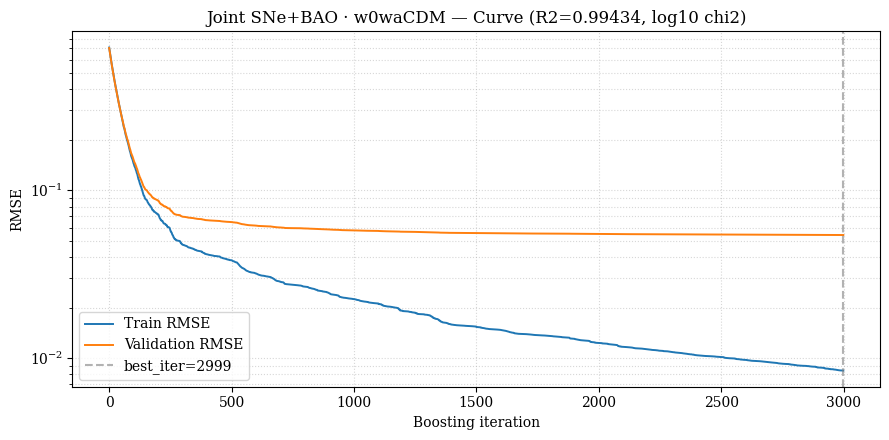

In [8]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    early_stopping_min_delta=1e-6, 
    early_stopping_rounds=200,
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"Joint SNe+BAO · w0waCDM — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $H_0$ vs $\Omega_m$  ({'w0': -0.9265271424133511, 'wa': -0.3401189054700916}) ---
  computing theory (parallel)...


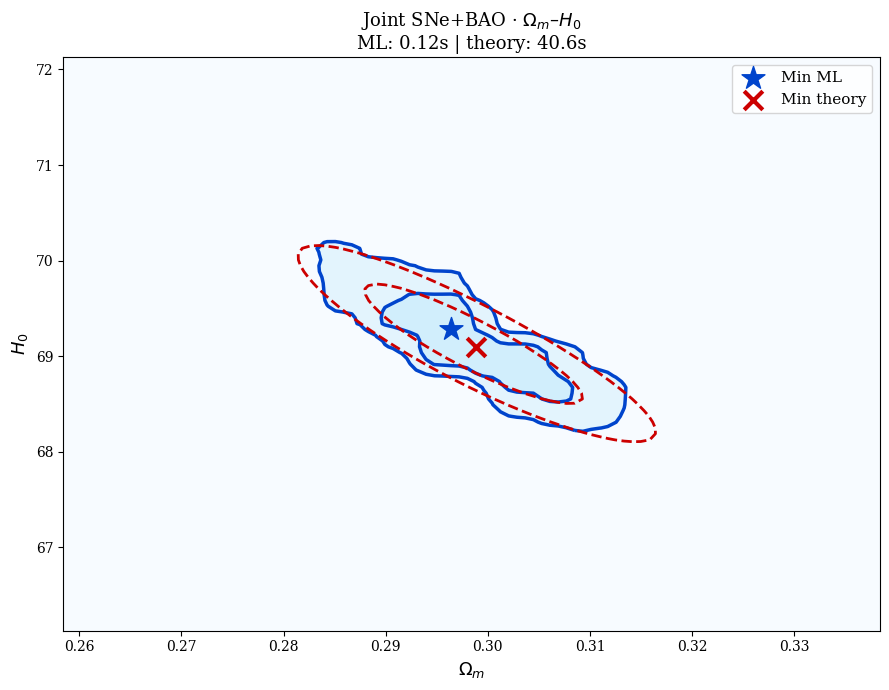

--- $w_0$ vs $\Omega_m$  ({'H0': 69.12902056755537, 'wa': -0.3401189054700916}) ---
  computing theory (parallel)...


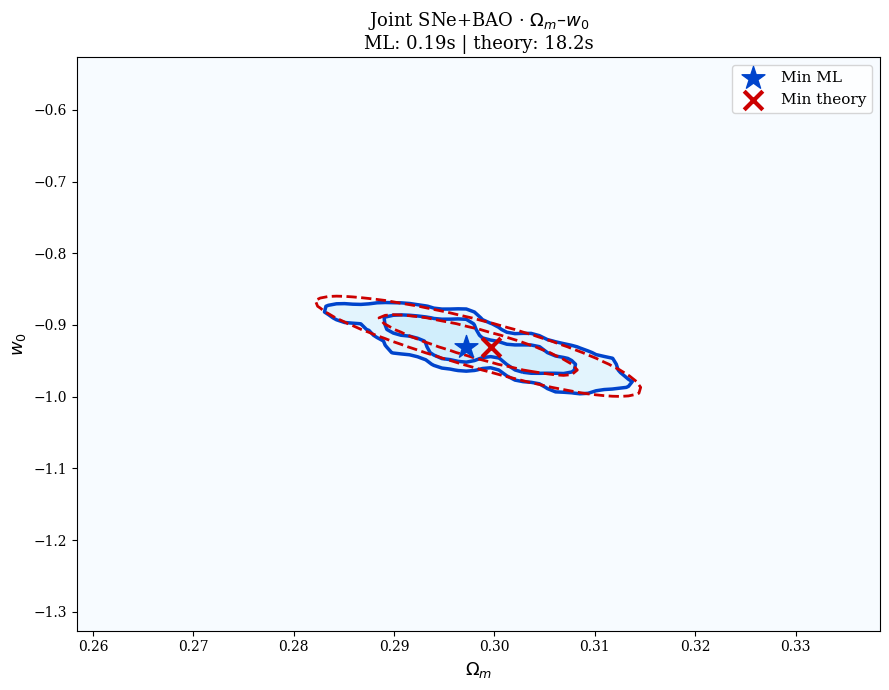

--- $w_a$ vs $\Omega_m$  ({'H0': 69.12902056755537, 'w0': -0.9265271424133511}) ---
  computing theory (parallel)...


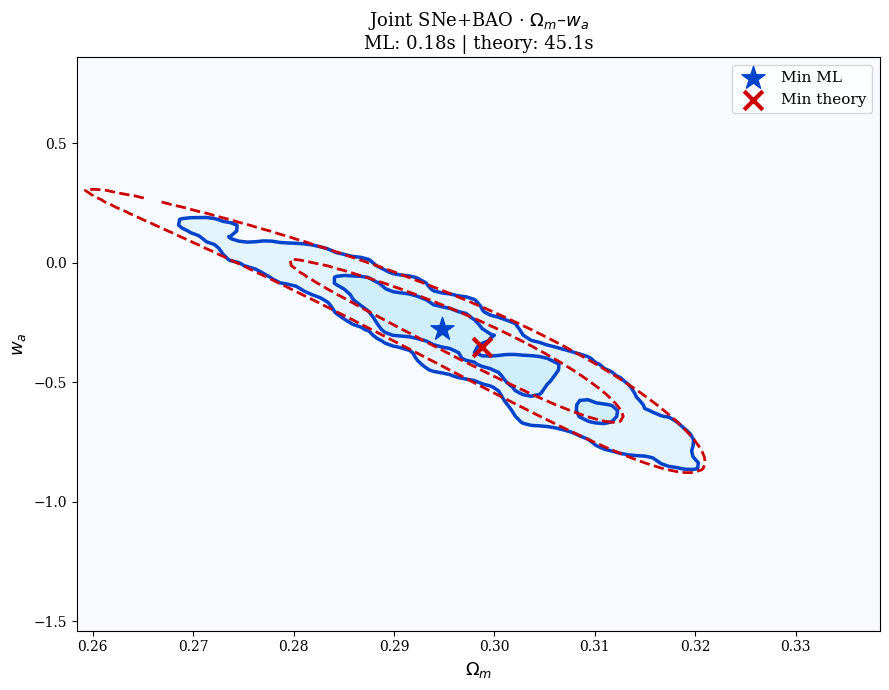

--- $w_0$ vs $H_0$  ({'Om': 0.2984036476448671, 'wa': -0.3401189054700916}) ---
  computing theory (parallel)...


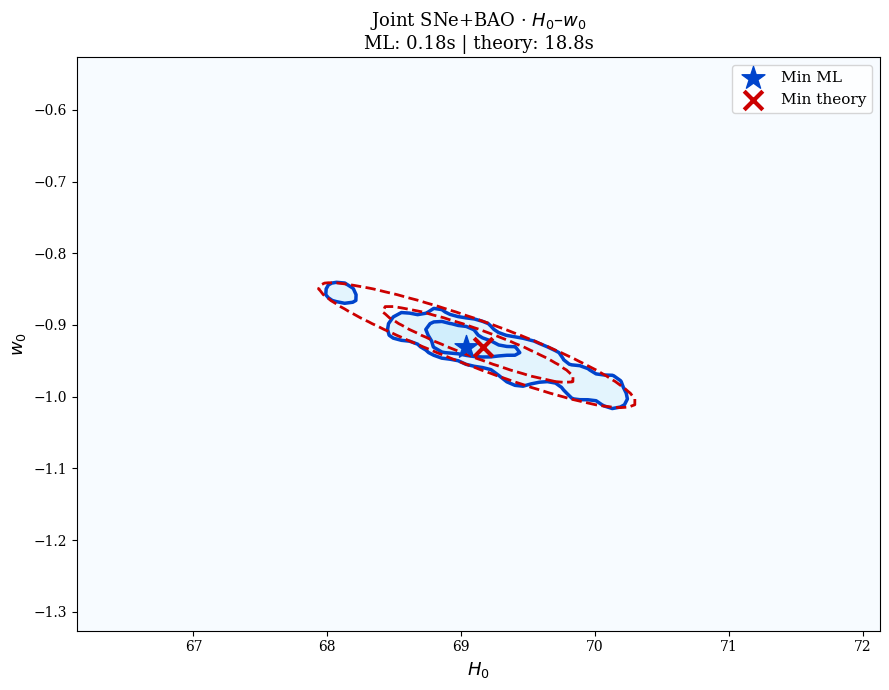

--- $w_a$ vs $H_0$  ({'Om': 0.2984036476448671, 'w0': -0.9265271424133511}) ---
  computing theory (parallel)...


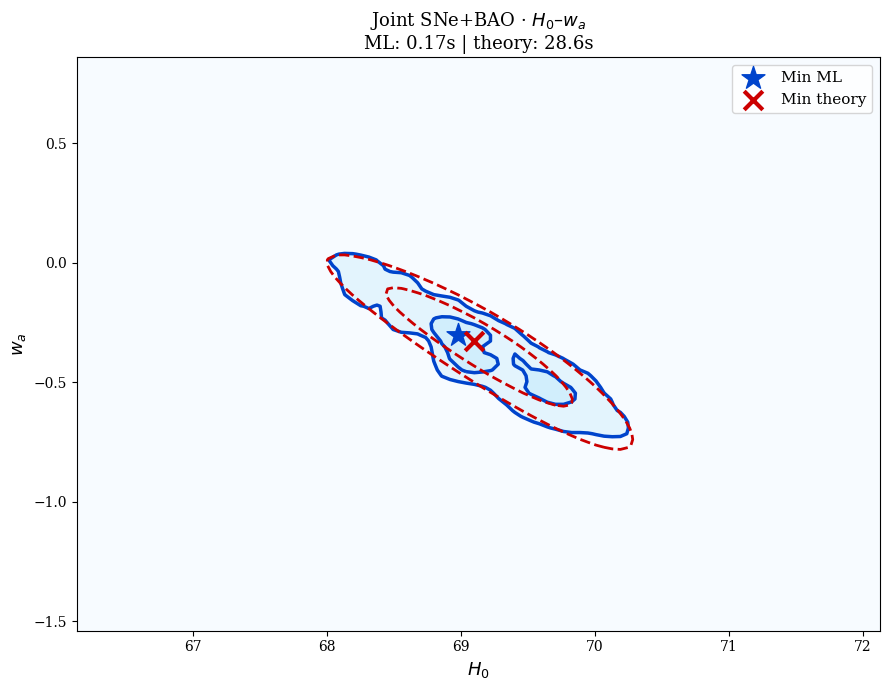

--- $w_a$ vs $w_0$  ({'Om': 0.2984036476448671, 'H0': 69.12902056755537}) ---
  computing theory (parallel)...


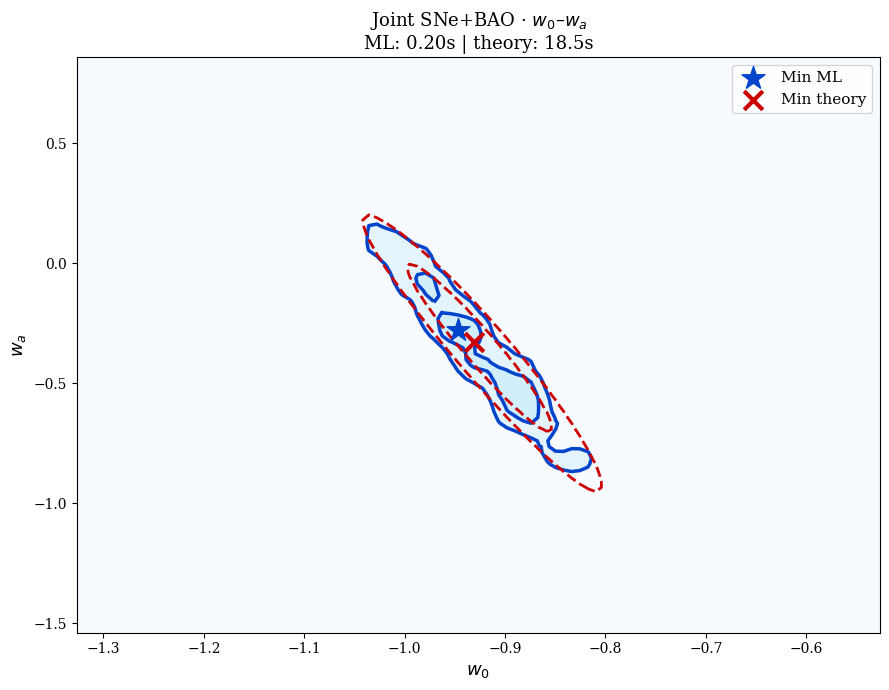

In [9]:
common = dict(res=100, sigma=0.8, theory_threshold=12)
# Contour window centered on the auto-detected best-fit.
RANGES = dict(
    Om=(REF['Om']-0.04, REF['Om']+0.04),
    H0=(REF['H0']-3.0, REF['H0']+3.0),
    w0=(REF['w0']-0.4, REF['w0']+0.4),
    wa=(REF['wa']-1.2, REF['wa']+1.2),
)
LABELS = dict(Om=r"$\Omega_m$", H0=r"$H_0$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','H0'), ('Om','w0'), ('Om','wa'),
             ('H0','w0'), ('H0','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"Joint SNe+BAO · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


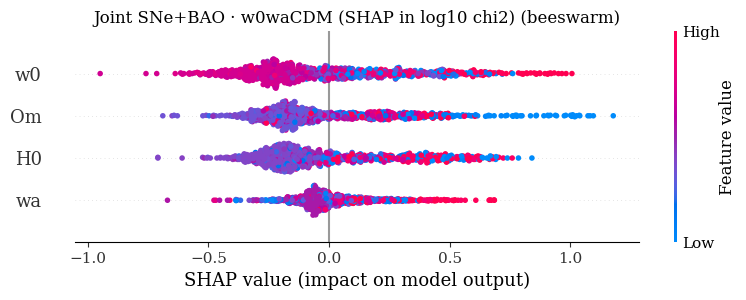

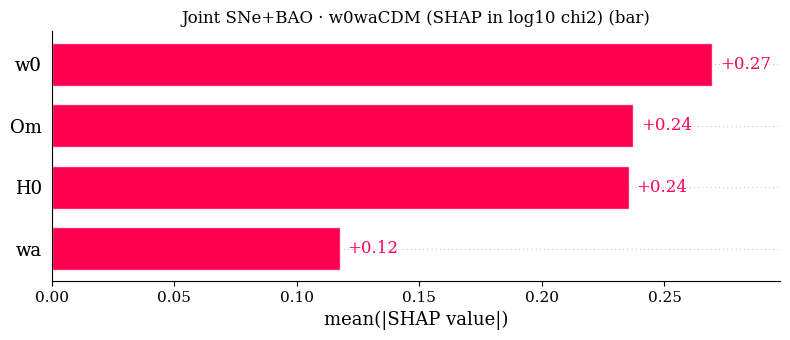

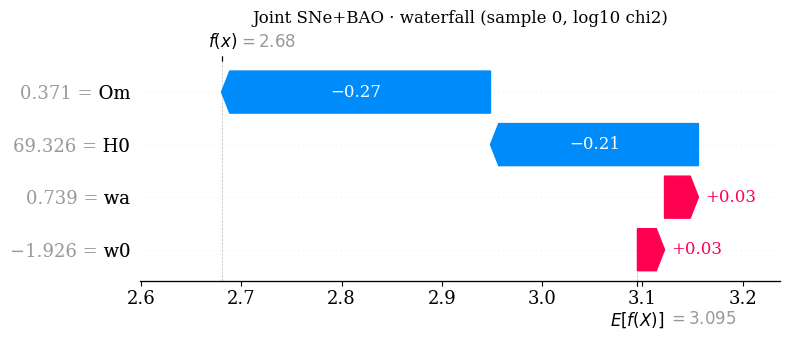

<Figure size 640x480 with 0 Axes>

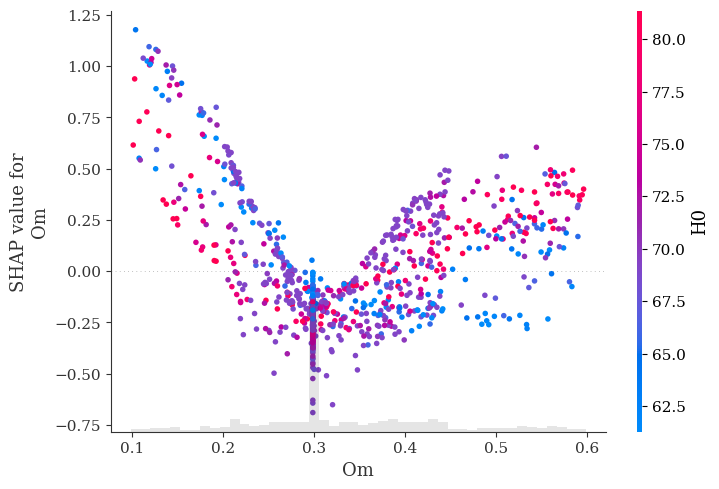

<Figure size 640x480 with 0 Axes>

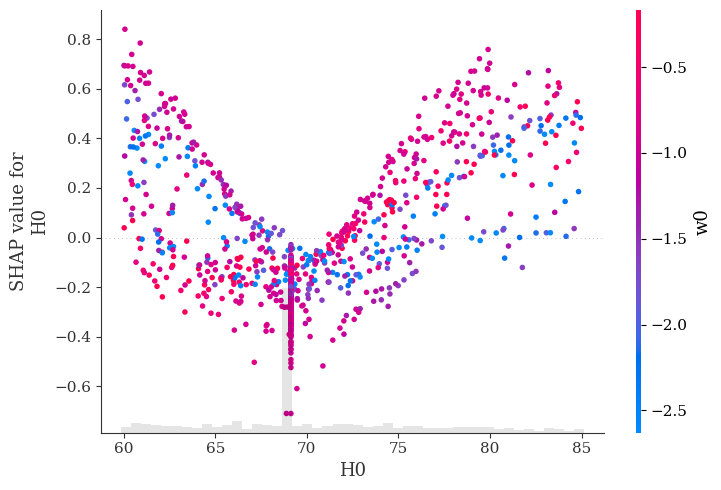

<Figure size 640x480 with 0 Axes>

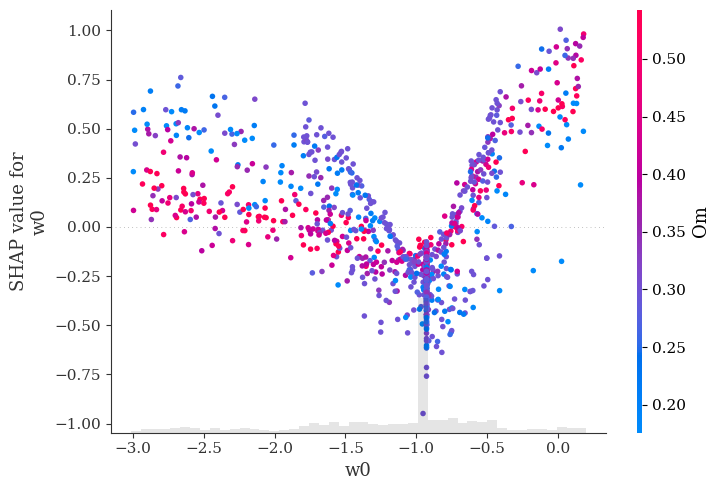

<Figure size 640x480 with 0 Axes>

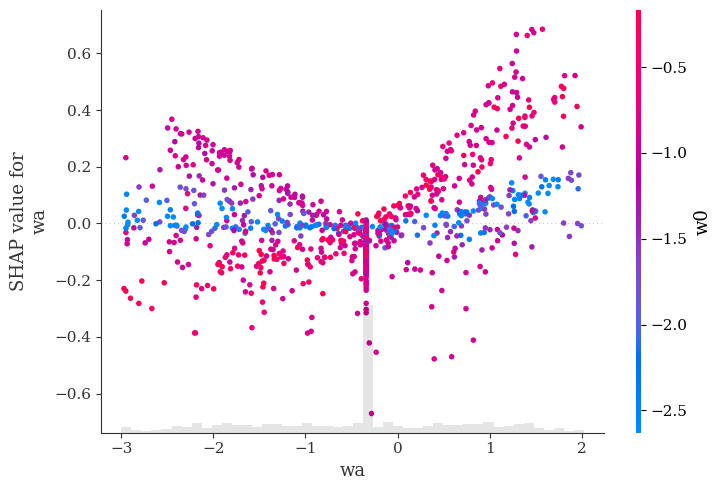

[]

In [12]:
shap_v, X_s = shap_summary(model, info["X_val"], save_dir=None, prefix=SECTION,
                           title="Joint SNe+BAO · w0waCDM (SHAP in log10 chi2)", show=True)
shap_waterfall(shap_v, idx=0, save_path=None,
               title="Joint SNe+BAO · waterfall (sample 0, log10 chi2)", show=True)
shap_dependence_all(shap_v, X_s, save_dir=None, prefix=SECTION, show=True)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=4) ---
  loading CPU booster copy...
  step   200/5000  |  46 it/s  |  ETA 103s  |  acc 0.26  |  diagonal
  step   400/5000  |  47 it/s  |  ETA 98s  |  acc 0.26  |  multivar
  step   600/5000  |  48 it/s  |  ETA ≤6s  |  acc 0.23  |  τ=47.8  ESS=2141/5000  |  multivar
  step   800/5000  |  39 it/s  |  ETA ≤5s  |  acc 0.22  |  τ=61.7  ESS=3317/5000  |  multivar
  step  1000/5000  |  40 it/s  |  ETA ≤4s  |  acc 0.22  |  τ=76.4  ESS=4020/5000  |  multivar
  step  1200/5000  |  40 it/s  |  ETA ≤0s  |  acc 0.21  |  τ=76.5  ESS=5356/5000  |  multivar
  done: 30.0s  |  40 it/s  |  acceptance 0.212  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=76.5  |  ESS=5362
Removed no burn in


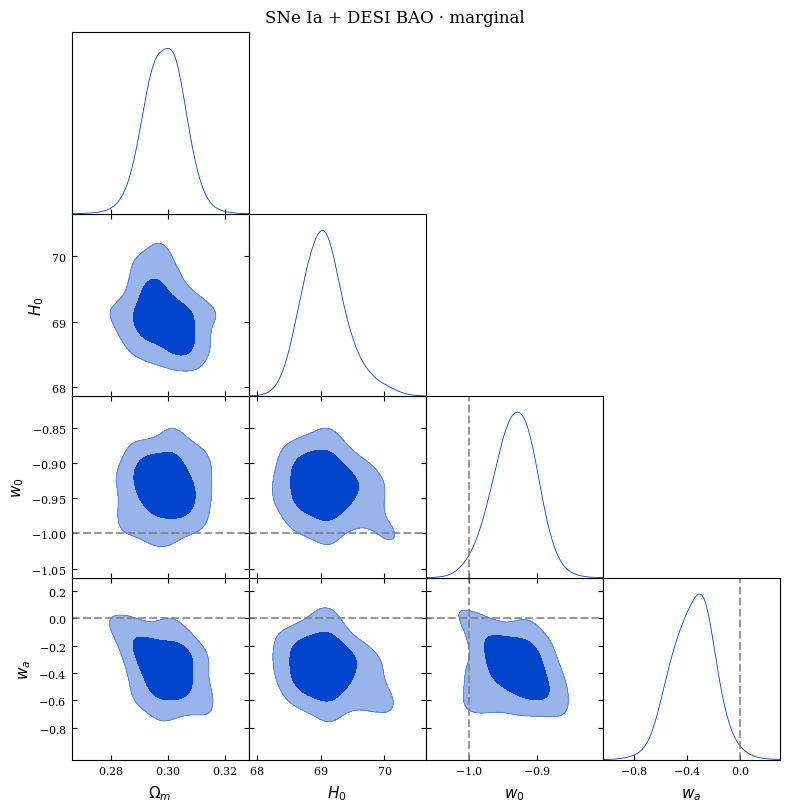

array([[ 2.85194308e-01,  6.95080414e+01, -9.15742040e-01,
        -3.76482636e-01],
       [ 2.81928539e-01,  6.92080154e+01, -9.86466527e-01,
        -6.79501072e-02],
       [ 2.90995061e-01,  6.87688828e+01, -8.98616850e-01,
        -5.69393694e-01],
       ...,
       [ 2.91617572e-01,  6.92024536e+01, -9.86900270e-01,
        -1.70802981e-01],
       [ 3.02112609e-01,  6.84591904e+01, -9.37983990e-01,
        -2.60432541e-01],
       [ 3.01619500e-01,  6.90983047e+01, -9.35598314e-01,
        -2.61269271e-01]], shape=(410112, 4))

In [13]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="SNe Ia + DESI BAO · marginal",
    save_path=None,
    show=True,
)

## <a id="4-2"></a>4.2 SNe vs BAO comparison with Om = 0.40 +/- 0.10 prior

**Not a joint with prior** — a robustness experiment: SNe and BAO are evaluated
**separately** on the **same** point cloud, **each with the same Gaussian
penalty** on Om, and a **single XGBoost is trained per probe** so we can
compare via SHAP how each dataset responds to the prior individually.

### Recipe

- H0 fixed at **70.0**.
- Sampling: Om from the **Gaussian prior** (`np.random.normal(0.40, 0.10, N)`,
  clipped to [0.05, 0.8]), w0 ~ U(-2.0, 0.2), wa ~ U(-3.0, 2.0). **20 000 points.**
- Two chi2: `chi2_sne` and `chi2_bao`, each with `((Om - 0.40) / 0.10)^2` added.
- **Balanced filtering**: top-8000 points per probe before training (each model
  trains on its 8k best points).
- Two light XGBoost models: `n_estimators=1500, learning_rate=0.02, max_depth=6`.
- Outputs: SHAP beeswarm + dependence plots (w0 vs Om, wa vs Om) per probe.

### Why not a joint

A joint would add both chi2 into a single likelihood; we would lose the ability
to compare **which probe is pushing the parameters harder** under the prior.
That comparison is the whole point here.


In [7]:
SECTION = "4_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
H0_FIXED = 70.0

PRIOR_OM_MEAN  = 0.40
PRIOR_OM_SIGMA = 0.10

def chi2_sne_with_prior(Om, w0, wa):
    return (chi2_sne(sne, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)
            + gaussian_prior(Om, PRIOR_OM_MEAN, PRIOR_OM_SIGMA))

def chi2_bao_with_prior(Om, w0, wa):
    return (chi2_bao(bao, Om=Om, w0=w0, wa=wa, H0=H0_FIXED, rd=PLANCK_RD)
            + gaussian_prior(Om, PRIOR_OM_MEAN, PRIOR_OM_SIGMA))


In [8]:
def builder():
    # Om sampled from the Gaussian prior; w0/wa uniform. No slices, no separate random box.
    N = 20_000
    rng = np.random.default_rng(42)
    Om_arr = np.clip(rng.normal(PRIOR_OM_MEAN, PRIOR_OM_SIGMA, N), 0.05, 0.8)
    w0_arr = rng.uniform(-2.0, 0.2, N)
    wa_arr = rng.uniform(-3.0, 2.0, N)

    print(f"Computing chi2_SNe + chi2_BAO over {N} points (both probes per point)...")
    chi2_s = np.empty(N)
    chi2_b = np.empty(N)
    import time as _t
    t0 = _t.time()
    for i in range(N):
        chi2_s[i] = chi2_sne_with_prior(Om_arr[i], w0_arr[i], wa_arr[i])
        chi2_b[i] = chi2_bao_with_prior(Om_arr[i], w0_arr[i], wa_arr[i])
        if i and i % 2000 == 0:
            print(f"  {i}/{N}  ({_t.time()-t0:.1f}s)", end="\r")
    print(f"  → {N}/{N} en {_t.time()-t0:.1f}s")

    df = pd.DataFrame({
        'Om': Om_arr, 'w0': w0_arr, 'wa': wa_arr,
        'chi2_sne': chi2_s, 'chi2_bao': chi2_b,
    })
    df.to_csv(DATASET_CSV, index=False)
    print(f"  saved: {DATASET_CSV}  ({len(df)} rows)")
    return df

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2_SNe = {df['chi2_sne'].min():.2f}")
print(f"min chi2_BAO = {df['chi2_bao'].min():.2f}")

# Per-probe best-fit (informational)
bf_sne = df.loc[df['chi2_sne'].idxmin(), FEATURES].to_dict()
bf_bao = df.loc[df['chi2_bao'].idxmin(), FEATURES].to_dict()
print(f"Best-fit SNe:  {bf_sne}")
print(f"Best-fit BAO:  {bf_bao}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/4_2_dataset.csv)
Computing chi2_SNe + chi2_BAO over 20000 points (both probes per point)...
  → 20000/20000 en 1554.2s
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/4_2_dataset.csv  (20000 rows)
min chi2_SNe = 1462.64
min chi2_BAO = 12.81
Best-fit SNe:  {'Om': 0.39810174003191384, 'w0': -0.8484141613280602, 'wa': -2.2838416409134124}
Best-fit BAO:  {'Om': 0.27622741917027216, 'w0': -1.0876464752742112, 'wa': 0.5006989771738528}


In [9]:
# Balanced filtering: top-8000 points per probe
N_TOP = 8_000

df_sne_clean = df.sort_values('chi2_sne').head(N_TOP).copy()
df_bao_clean = df.sort_values('chi2_bao').head(N_TOP).copy()
print(f"Top-{N_TOP} SNe: rango chi2 [{df_sne_clean['chi2_sne'].min():.2f}, {df_sne_clean['chi2_sne'].max():.2f}]")
print(f"Top-{N_TOP} BAO: rango chi2 [{df_bao_clean['chi2_bao'].min():.2f}, {df_bao_clean['chi2_bao'].max():.2f}]")

# Lighter trees than the global recipe
HP_LEGACY = dict(n_estimators=1500, learning_rate=0.02, max_depth=6)

print("\n--- Modelo SNe ---")
model_sne, info_sne = train_xgb(
    df_sne_clean, features=FEATURES, target='chi2_sne',
    hp_overrides=HP_LEGACY, test_size=0.15,
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
    drop_chi2_bad=None,  # ya filtrado por sort + head
)

print("\n--- Modelo BAO ---")
model_bao, info_bao = train_xgb(
    df_bao_clean, features=FEATURES, target='chi2_bao',
    hp_overrides=HP_LEGACY, test_size=0.15,
    cache_path=None,
    force_retrain=FORCE_RETRAIN,
    drop_chi2_bad=None,
)

print(f"\nR² SNe = {info_sne['r2']:.5f}  |  R² BAO = {info_bao['r2']:.5f}")


Top-8000 SNe: rango chi2 [1462.64, 1536.26]
Top-8000 BAO: rango chi2 [12.81, 1289.84]

--- Modelo SNe ---
  training: 17.68s | R2=0.97204 | best_iter=1489/1500  (early stop, ~1% saved)
  model cached: 4_2_sne_model.ubj

--- Modelo BAO ---
  training: 13.51s | R2=0.96980 | best_iter=1499/1500
  model cached: 4_2_bao_model.ubj

R² SNe = 0.97204  |  R² BAO = 0.96980


--- SHAP: SNe ---
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_SNe_shap_beeswarm.png


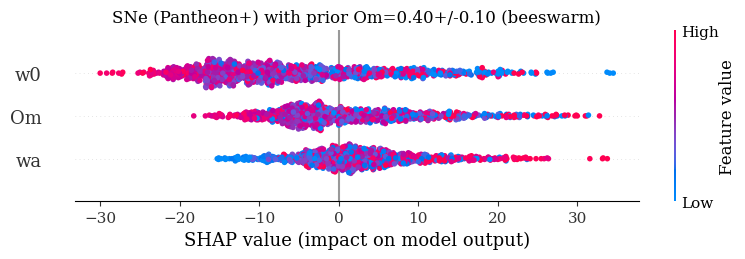

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_SNe_shap_bar.png


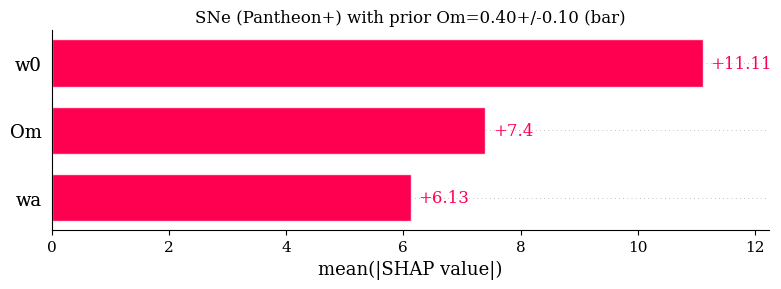


--- SHAP: BAO ---
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_BAO_shap_beeswarm.png


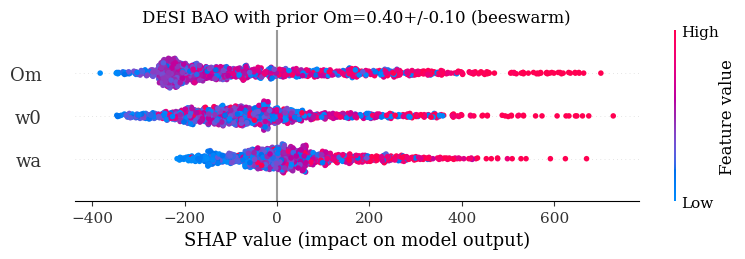

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_BAO_shap_bar.png


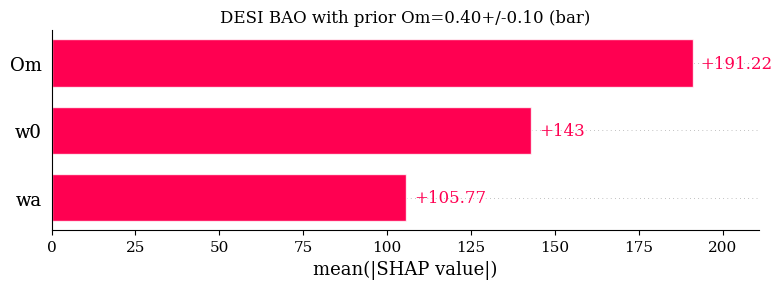


--- Dependence plots (interaction = Om) ---
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_SNe_dep_w0_Om.png


<Figure size 800x600 with 0 Axes>

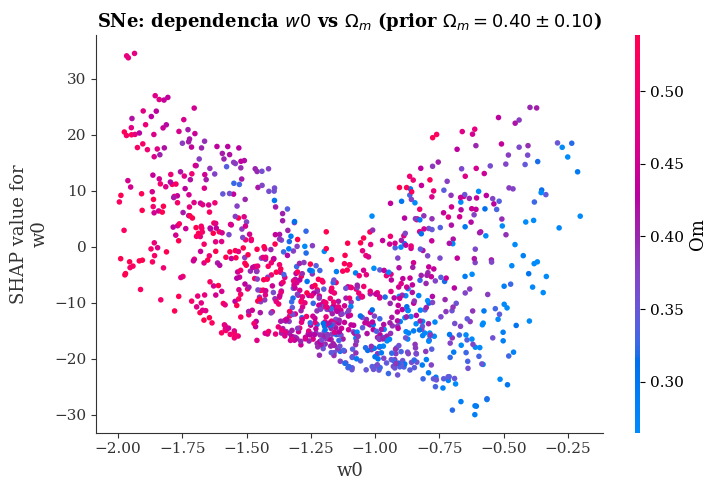

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_SNe_dep_wa_Om.png


<Figure size 800x600 with 0 Axes>

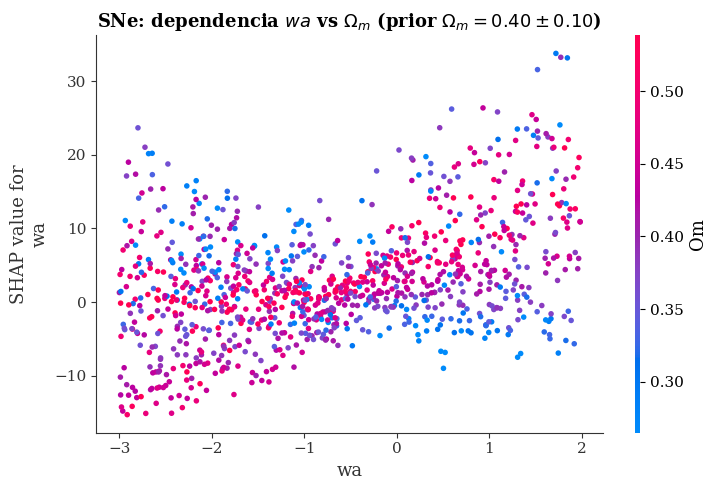

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_BAO_dep_w0_Om.png


<Figure size 800x600 with 0 Axes>

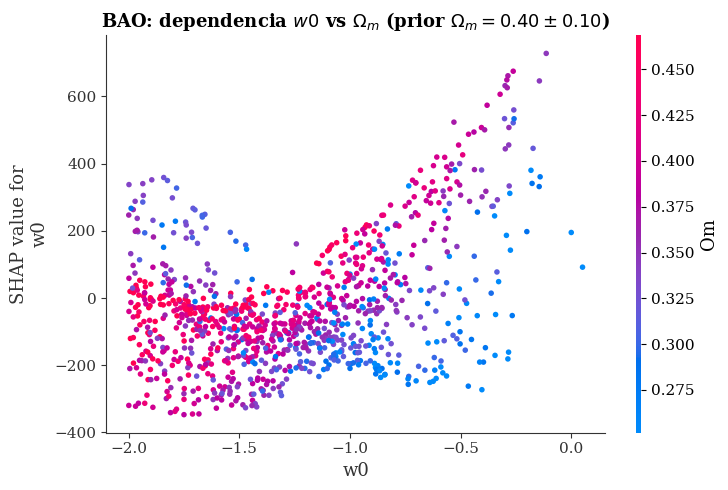

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_BAO_dep_wa_Om.png


<Figure size 800x600 with 0 Axes>

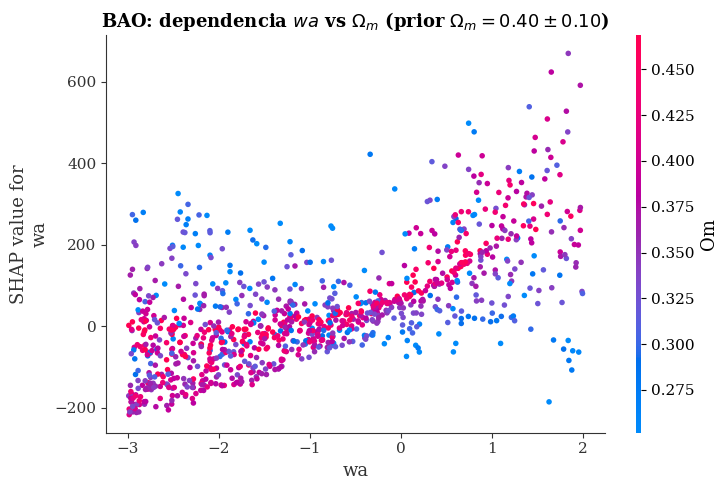

In [10]:
# SHAP comparison: SNe beeswarm vs BAO beeswarm + dependence plots for
# the most informative pairs (w0 vs Om, wa vs Om) per probe.

import shap

print("--- SHAP: SNe ---")
shap_sne, X_sne_s = shap_summary(
    model_sne, info_sne['X_val'],
    save_dir=None, prefix=f"{SECTION}_SNe",
    title="SNe (Pantheon+) with prior Om=0.40+/-0.10",
    show=True,
)

print("\n--- SHAP: BAO ---")
shap_bao, X_bao_s = shap_summary(
    model_bao, info_bao['X_val'],
    save_dir=None, prefix=f"{SECTION}_BAO",
    title="DESI BAO with prior Om=0.40+/-0.10",
    show=True,
)

# Dependence plots: w0 vs Om, wa vs Om per probe
print("\n--- Dependence plots (interaction = Om) ---")
for tag, sv, X_s in [("SNe", shap_sne, X_sne_s), ("BAO", shap_bao, X_bao_s)]:
    for feat in ('w0', 'wa'):
        plt.figure(figsize=(8, 6))
        shap.dependence_plot(feat, sv.values, X_s, interaction_index='Om', show=False)
        plt.title(fr"{tag}: dependencia ${feat}$ vs $\Omega_m$ (prior $\Omega_m=0.40\pm0.10$)",
                  fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_beeswarm.png


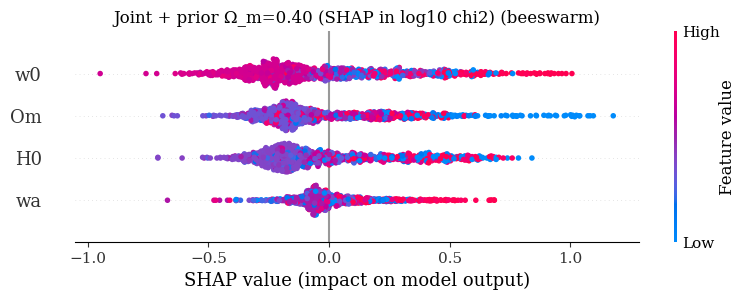

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_bar.png


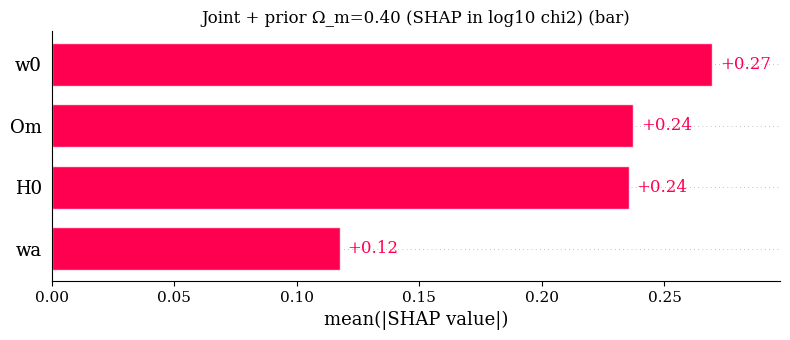

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_waterfall.png


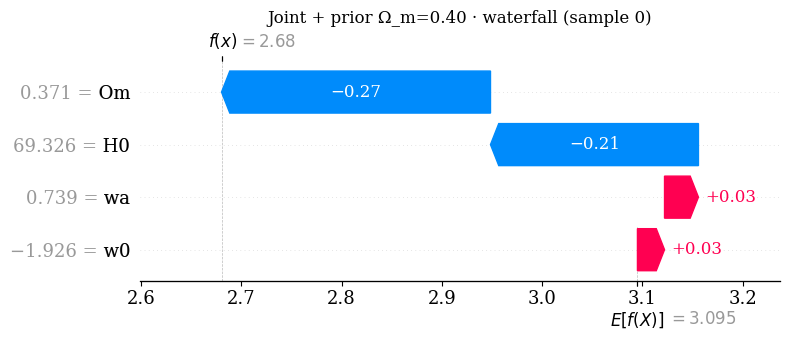

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

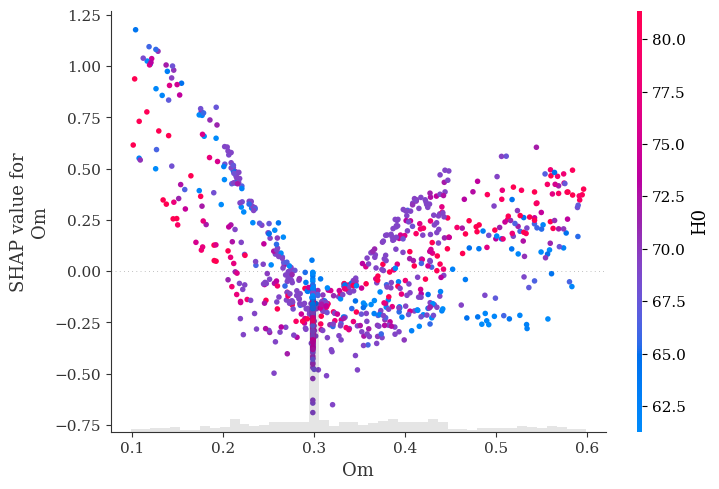

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

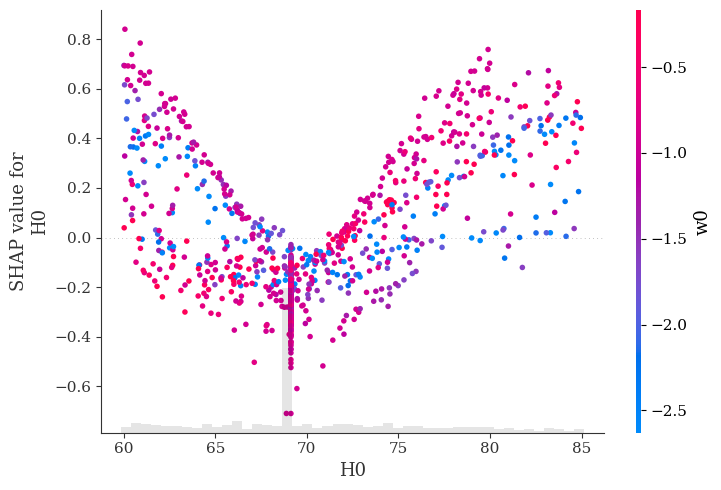

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_w0.png


<Figure size 640x480 with 0 Axes>

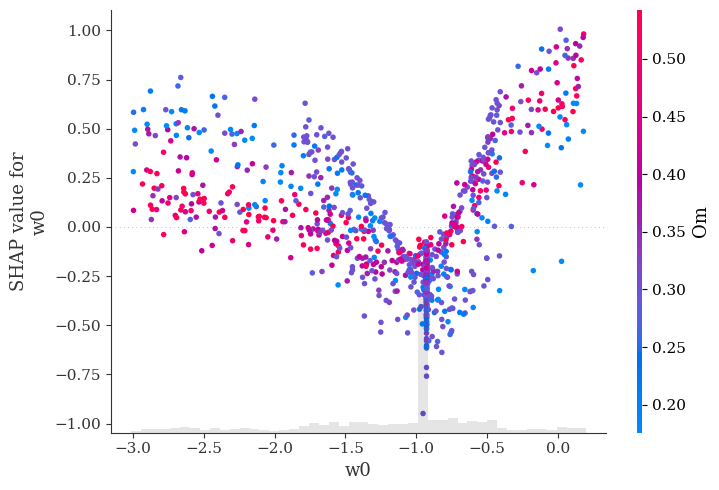

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_wa.png


<Figure size 640x480 with 0 Axes>

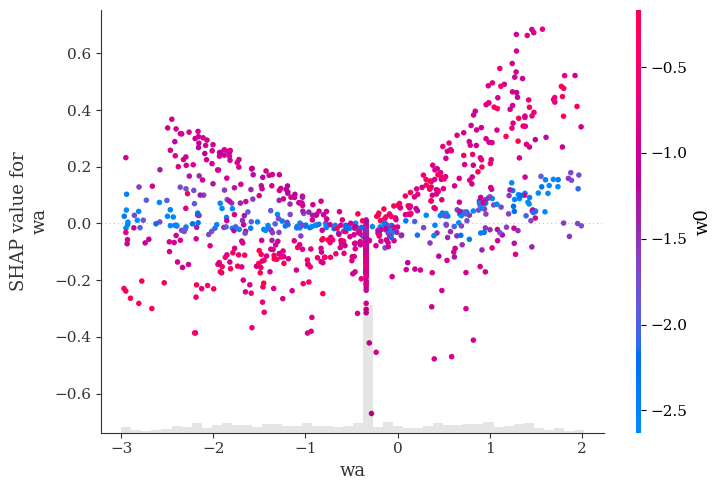

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_2_shap_wa.png')]

In [11]:
shap_v, X_s = shap_summary(model, info["X_val"], save_dir=None, prefix=SECTION,
                           title="Joint + prior Ω_m=0.40 (SHAP in log10 chi2)", show=True)
shap_waterfall(shap_v, idx=0, save_path=None,
               title="Joint + prior Ω_m=0.40 · waterfall (sample 0)", show=True)
shap_dependence_all(shap_v, X_s, save_dir=None, prefix=SECTION, show=True)

## <a id="4-3"></a>4.3 w0–wa ellipses: SNe vs BAO overlaid

**Goal:** show the COMPLEMENTARY degeneracies of each probe in (w0, wa), with
Om=0.315 and H0=67.36 fixed at the Planck fiducial. The two ellipses cross at
different angles — that is why combining SNe + BAO tightens the contours so much.

**No ML**: 2D space, so we evaluate a 60 x 60 theory grid directly with Astropy.

Cepheids: **YES** on the SNe side (`use_cepheid_calibrators=True`).


In [12]:
SECTION = "4_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"

FIXED_OM = 0.315
FIXED_H0 = 67.36

def chi2_sne_w0wa(w0, wa):
    return chi2_sne(sne, model="Flatw0waCDM",
                    Om=FIXED_OM, H0=FIXED_H0, w0=w0, wa=wa,
                    M="marginalize", use_cepheid_calibrators=True)

def chi2_bao_w0wa(w0, wa):
    return chi2_bao(bao, Om=FIXED_OM, w0=w0, wa=wa, H0=FIXED_H0, rd=PLANCK_RD)

In [13]:
def builder():
    res = 60
    w0_r = np.linspace(-1.8, -0.4, res)
    wa_r = np.linspace(-2.5, 1.5, res)
    rows = []
    for wa in wa_r:
        for w0 in w0_r:
            rows.append((w0, wa, chi2_sne_w0wa(w0, wa), chi2_bao_w0wa(w0, wa)))
    df = pd.DataFrame(rows, columns=['w0', 'wa', 'chi2_sne', 'chi2_bao'])
    df.to_csv(DATASET_CSV, index=False)
    print(f"  saved: {DATASET_CSV}  ({len(df)} rows)")
    return df

if DATASET_CSV.exists():
    print(f"Loading cached grid: {DATASET_CSV}")
    df = pd.read_csv(DATASET_CSV)
else:
    print("Building 60x60 grid (1-2 min)...")
    df = builder()
print(f"  min χ² SNe = {df['chi2_sne'].min():.2f}, min χ² BAO = {df['chi2_bao'].min():.2f}")

Building 60x60 grid (1-2 min)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/4_3_dataset.csv  (3600 rows)
  min χ² SNe = 1488.85, min χ² BAO = 8.26


Best-fit SNe: w₀=-0.780, wₐ=-0.941
Best-fit BAO: w₀=-0.827, wₐ=-0.534
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_3_w0_wa_overlay.png


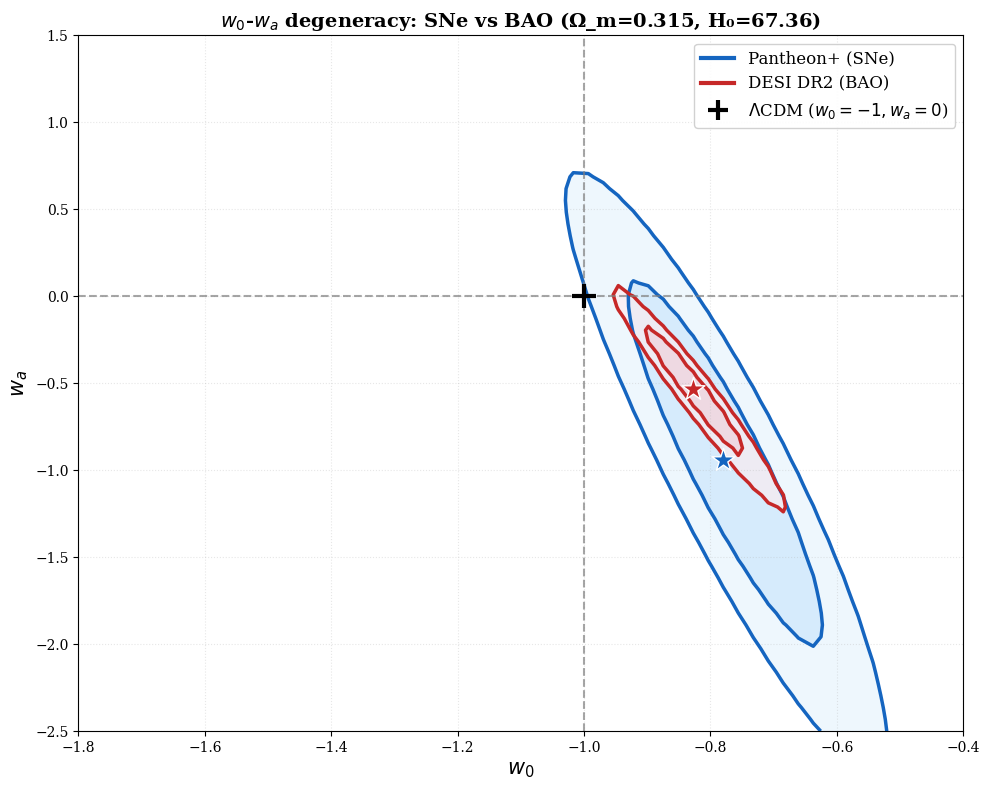

In [14]:
res = int(np.sqrt(len(df)))
w0_grid = np.sort(df['w0'].unique())
wa_grid = np.sort(df['wa'].unique())
XX, YY = np.meshgrid(w0_grid, wa_grid)

piv_sne = df.pivot(index='wa', columns='w0', values='chi2_sne').values
piv_bao = df.pivot(index='wa', columns='w0', values='chi2_bao').values
delta_sne = piv_sne - piv_sne.min()
delta_bao = piv_bao - piv_bao.min()

i_sne = np.unravel_index(np.argmin(piv_sne), piv_sne.shape)
i_bao = np.unravel_index(np.argmin(piv_bao), piv_bao.shape)
bf_sne = (XX[i_sne], YY[i_sne])
bf_bao = (XX[i_bao], YY[i_bao])
print(f"Best-fit SNe: w₀={bf_sne[0]:.3f}, wₐ={bf_sne[1]:.3f}")
print(f"Best-fit BAO: w₀={bf_bao[0]:.3f}, wₐ={bf_bao[1]:.3f}")

fig, ax = plt.subplots(figsize=(10, 8))
levels = [2.30, 6.18]

ax.contourf(XX, YY, delta_sne, levels=[0, 2.30, 6.18], colors=['#bbdefb', '#e3f2fd'], alpha=0.6)
ax.contour(XX, YY, delta_sne, levels=levels, colors='#1565c0', linewidths=2.5)
ax.scatter(*bf_sne, marker='*', s=300, color='#1565c0', edgecolors='white', zorder=10)

ax.contourf(XX, YY, delta_bao, levels=[0, 2.30, 6.18], colors=['#ffcdd2', '#ffebee'], alpha=0.6)
ax.contour(XX, YY, delta_bao, levels=levels, colors='#c62828', linewidths=2.5)
ax.scatter(*bf_bao, marker='*', s=300, color='#c62828', edgecolors='white', zorder=10)

ax.axvline(-1.0, color='gray', ls='--', alpha=0.7)
ax.axhline(0.0, color='gray', ls='--', alpha=0.7)
ax.scatter(-1.0, 0.0, marker='+', s=300, color='black', linewidth=3, zorder=15)

ax.set_xlim(-1.8, -0.4); ax.set_ylim(-2.5, 1.5)
ax.set_xlabel(r"$w_0$", fontsize=15); ax.set_ylabel(r"$w_a$", fontsize=15)
ax.set_title(fr"$w_0$-$w_a$ degeneracy: SNe vs BAO (Ω_m={FIXED_OM}, H₀={FIXED_H0})", fontsize=14, fontweight='bold')

handles = [
    mlines.Line2D([], [], color='#1565c0', lw=3, label='Pantheon+ (SNe)'),
    mlines.Line2D([], [], color='#c62828', lw=3, label='DESI DR2 (BAO)'),
    mlines.Line2D([], [], color='black', marker='+', linestyle='None', markersize=15, markeredgewidth=3, label=r'$\Lambda$CDM ($w_0=-1, w_a=0$)'),
]
ax.legend(handles=handles, loc='upper right', fontsize=12, framealpha=0.9)
ax.grid(alpha=0.3, ls=':')
fig.tight_layout()

plt.show()

## <a id="4-4"></a>4.4 1D constraint on wa — SNe vs BAO

**Goal:** 1D scan over wa with `Om=0.315, H0=67.36, w0=-1` FIXED (LCDM anchor).
Quantifies how strongly each probe constrains wa alone.

Plot: Delta-chi2(wa) per dataset + extraction of the 1-sigma error (where
Delta-chi2 = 1). Narrower parabolas indicate stronger constraint.

No ML — 100 evaluations per dataset are enough for a smooth 1D curve.


In [15]:
SECTION = "4_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"

FIXED_OM = 0.315
FIXED_H0 = 67.36
FIXED_W0 = -1.0

def chi2_sne_1d(wa):
    return chi2_sne(sne, model="Flatw0waCDM",
                    Om=FIXED_OM, H0=FIXED_H0, w0=FIXED_W0, wa=wa,
                    M="marginalize", use_cepheid_calibrators=True)

def chi2_bao_1d(wa):
    return chi2_bao(bao, Om=FIXED_OM, w0=FIXED_W0, wa=wa, H0=FIXED_H0, rd=PLANCK_RD)

In [16]:
def builder():
    was = np.linspace(-2.5, 1.5, 100)
    rows = [(wa, chi2_sne_1d(wa), chi2_bao_1d(wa)) for wa in was]
    df = pd.DataFrame(rows, columns=['wa', 'chi2_sne', 'chi2_bao'])
    df.to_csv(DATASET_CSV, index=False)
    print(f"  saved: {DATASET_CSV}  ({len(df)} rows)")
    return df

if DATASET_CSV.exists():
    print(f"Loading cached dataset: {DATASET_CSV}")
    df = pd.read_csv(DATASET_CSV)
else:
    print("Building 1D scan (100 evaluations per dataset)...")
    df = builder()

df['delta_sne'] = df['chi2_sne'] - df['chi2_sne'].min()
df['delta_bao'] = df['chi2_bao'] - df['chi2_bao'].min()

def extract_1sigma(delta_col, name):
    wa_v = df['wa'].values
    d_v = df[delta_col].values
    i_min = int(np.argmin(d_v))
    bf = wa_v[i_min]
    try:
        wa_minus = np.interp(1.0, d_v[:i_min][::-1], wa_v[:i_min][::-1])
        wa_plus  = np.interp(1.0, d_v[i_min:],       wa_v[i_min:])
        print(f"  [{name}] wₐ = {bf:+.3f}  +{wa_plus-bf:.3f} / -{bf-wa_minus:.3f}")
    except Exception:
        print(f"  [{name}] wₐ = {bf:+.3f}  (error fuera de rango)")

print("--- 1D constraints on wa with w0=-1 fixed ---")
extract_1sigma('delta_sne', 'Pantheon+ SNe')
extract_1sigma('delta_bao', 'DESI BAO')

Building 1D scan (100 evaluations per dataset)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/4_4_dataset.csv  (100 rows)
--- 1D constraints on wa with w0=-1 fixed ---
  [Pantheon+ SNe] wₐ = +0.409  +0.255 / -0.295
  [DESI BAO] wₐ = +0.207  +0.075 / -0.047


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/04_SN+BAO/4_4_delta_chi2_wa.png


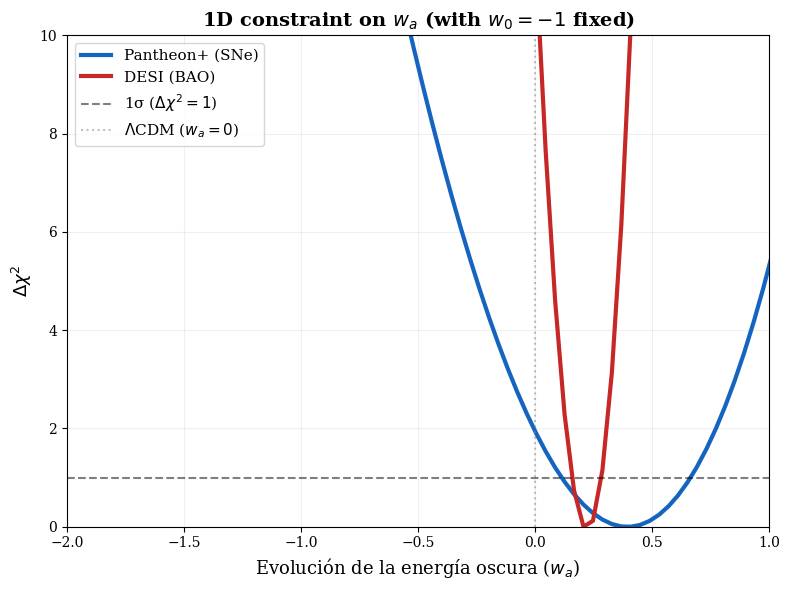

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df['wa'], df['delta_sne'], lw=3, color='#1565c0', label='Pantheon+ (SNe)')
ax.plot(df['wa'], df['delta_bao'], lw=3, color='#c62828', label='DESI (BAO)')

ax.axhline(1.0, color='black', ls='--', alpha=0.5, label=r'1σ ($\Delta\chi^2 = 1$)')
ax.axvline(0.0, color='gray', ls=':', alpha=0.5, label=r'$\Lambda$CDM ($w_a = 0$)')

ax.set_xlim(-2.0, 1.0); ax.set_ylim(0, 10)
ax.set_xlabel(r"Evolución de la energía oscura ($w_a$)", fontsize=13)
ax.set_ylabel(r"$\Delta\chi^2$", fontsize=13)
ax.set_title(r"1D constraint on $w_a$ (with $w_0=-1$ fixed)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
fig.tight_layout()

plt.show()